# ETAPA 4 – MODELAGEM COM REGRESSÃO LOGÍSTICA

**Projeto:** Análise de Evasão Acadêmica  
**Equipe:** 3
**Integrantes:** Ana Julia Lidório, João Vitali e Lara Dondossola
**Data:** 26/05/2026

---

## Objetivo desta etapa

Nesta etapa, vocês irão construir um modelo simples de classificação para estimar a probabilidade de evasão acadêmica.

O modelo utilizado será a **Regressão Logística**, adequada para problemas em que a variável resposta possui duas classes, por exemplo:

- `0` = não desistiu
- `1` = desistiu

---

## Regra principal

> O objetivo não é apenas rodar o modelo. O objetivo é entender o que ele está dizendo.

Toda conclusão deve conter:

1. Um resultado numérico;
2. Uma interpretação;
3. Uma relação com o problema da evasão.


In [1]:
# Bibliotecas principais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carregar arquivo
from google.colab import files

# Modelagem
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Métricas
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

# Pré-processamento
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pd.set_option('display.max_columns', None)

In [2]:
uploaded = files.upload()

Saving clean_data_limpo (1).csv to clean_data_limpo (1).csv


# 1. Carregamento dos dados preparados

Utilizem o dataset final gerado na Etapa 3.

Esse dataset deve estar limpo, com variáveis tratadas e variáveis derivadas criadas.


In [3]:
# Ajustem o nome do arquivo conforme o dataset final da equipe
df = pd.read_csv('clean_data_limpo (1).csv')

display(df.head())
print('Formato do dataset:', df.shape)


,aluno_id,sexo,dist_cidade_km,desistiu,ingresso__1,ingresso__2,ingresso__3,ingresso__4,ingresso__5,ingresso__6,ingresso__9,ingresso__21,ingresso__22,ingresso__27,ingresso__28,ingresso__31,ingresso__33,ingresso__34,algebra_linear_e_geometria_analitica,calculo_i,comunicacao_e_expressao,fisica_i,fundamentos_de_quimica
0,1,1,15.5,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,1,1
1,2,1,12.1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1
2,8,1,16.0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,1,1,1
3,9,1,12.1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,1,0,1
4,11,1,25.1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,1


Formato do dataset: (99, 23)


# 2. Revisão das etapas anteriores

Antes de modelar, respondam:

1. Qual era a pergunta principal da equipe?
2. Quais padrões importantes foram encontrados na análise exploratória?
3. Quais variáveis foram criadas ou tratadas na Etapa 3?
4. O que vocês esperam que o modelo encontre?

Escrevam abaixo a resposta da equipe.


**Resposta da equipe:**

- Pergunta principal:  
- Padrões encontrados:  
- Variáveis importantes até agora:  
- O que esperamos do modelo:  


# 3. Definição da variável alvo

A variável alvo é aquilo que o modelo tentará prever.

Neste projeto, a variável alvo deve indicar evasão:

- `0` = não desistiu
- `1` = desistiu

Verifiquem se a coluna escolhida realmente está nesse formato.


In [4]:
# Ajustem o nome da variável alvo se necessário
target = 'desistiu'
print(df[target].value_counts(dropna=False))
print('Percentual:')
print(df[target].value_counts(normalize=True, dropna=False) * 100)


desistiu
0    71
1    28
Name: count, dtype: int64
Percentual:
desistiu
0    71.717172
1    28.282828
Name: proportion, dtype: float64


## Interpretação obrigatória

Respondam:

1. Existem mais alunos desistentes ou não desistentes?
2. A base está muito desbalanceada?
3. Isso pode impactar o modelo?


**Resposta da equipe:**



# 4. Escolha das variáveis explicativas

Escolham as variáveis que serão usadas para prever a evasão.

Importante:

- Não usem identificadores como `aluno_id` ou `novoCodigo`;
- Não usem variáveis que entregam a resposta diretamente;
- Evitem variáveis futuras, que só seriam conhecidas depois da evasão;
- Escolham variáveis coerentes com as etapas anteriores.


In [5]:
# Seleção focada estritamente na pergunta principal da equipe
variaveis_modelo = [
    'algebra_linear_e_geometria_analitica',
    'calculo_i',
    'comunicacao_e_expressao',
    'fisica_i',
    'fundamentos_de_quimica'
]

X = df[variaveis_modelo].copy()
y = df[target].copy()

print('Variáveis usadas no modelo:')
print(variaveis_modelo)

display(X.head())


Variáveis usadas no modelo:
['algebra_linear_e_geometria_analitica', 'calculo_i', 'comunicacao_e_expressao', 'fisica_i', 'fundamentos_de_quimica']


,algebra_linear_e_geometria_analitica,calculo_i,comunicacao_e_expressao,fisica_i,fundamentos_de_quimica
0,0,1,1,1,1
1,1,0,0,0,1
2,1,1,1,1,1
3,1,1,1,0,1
4,1,1,0,0,1


## Justificativa das variáveis

Para cada variável escolhida, preencham:

| Variável | Por que foi escolhida? | Relação esperada com evasão | Pode gerar viés? |
|---|---|---|---|
| | | | |
| | | | |
| | | | |


# 5. Tratamento final antes do modelo

A regressão logística só aceita variáveis numéricas.

Se existirem variáveis categóricas, será necessário transformar em colunas numéricas usando `pd.get_dummies()`.


In [6]:
# Transformar variáveis categóricas em variáveis numéricas
X = pd.get_dummies(X, drop_first=True)

# Remover linhas com valores nulos restantes, se houver
dados_modelo = pd.concat([X, y], axis=1).dropna()

X = dados_modelo.drop(columns=[target])
y = dados_modelo[target]

print('Formato final de X:', X.shape)
print('Formato final de y:', y.shape)
display(X.head())


Formato final de X: (99, 5)
Formato final de y: (99,)


,algebra_linear_e_geometria_analitica,calculo_i,comunicacao_e_expressao,fisica_i,fundamentos_de_quimica
0,0,1,1,1,1
1,1,0,0,0,1
2,1,1,1,1,1
3,1,1,1,0,1
4,1,1,0,0,1


## Interpretação obrigatória

Respondam:

1. Alguma variável categórica foi transformada?
2. Quantas linhas foram perdidas após remover nulos?
3. Isso pode influenciar o resultado?


**Resposta da equipe:**



# 6. Separação em treino e teste

O modelo será treinado com uma parte dos dados e avaliado em outra parte.

Isso evita avaliar o modelo nos mesmos dados que ele usou para aprender.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print('Treino:', X_train.shape)
print('Teste:', X_test.shape)

print('\nDistribuição no treino:')
print(y_train.value_counts(normalize=True) * 100)

print('\nDistribuição absoluta no treino:')
print(y_train.value_counts())

print('\nDistribuição no teste:')
print(y_test.value_counts(normalize=True) * 100)

print('\nDistribuição absoluta no teste:')
print(y_test.value_counts())

Treino: (74, 5)
Teste: (25, 5)

Distribuição no treino:
desistiu
0    71.621622
1    28.378378
Name: proportion, dtype: float64

Distribuição absoluta no treino:
desistiu
0    53
1    21
Name: count, dtype: int64

Distribuição no teste:
desistiu
0    72.0
1    28.0
Name: proportion, dtype: float64

Distribuição absoluta no teste:
desistiu
0    18
1     7
Name: count, dtype: int64


## Interpretação obrigatória

Respondam:

1. Quantos dados ficaram para treino?
2. Quantos dados ficaram para teste?
3. A proporção de desistentes ficou parecida em treino e teste?


**Resposta da equipe:**



# 7. Treinamento da Regressão Logística

Aqui será treinado o modelo.

Será utilizado um pipeline com padronização dos dados e regressão logística.


In [8]:
modelo = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000))
])

modelo.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg', LogisticRegression(max_iter=1000))])

# 8. Previsões do modelo

O modelo gera:

- Classe prevista: `0` ou `1`;
- Probabilidade de evasão.


In [9]:
y_pred = modelo.predict(X_test)
y_prob = modelo.predict_proba(X_test)[:, 1]

resultado_teste = X_test.copy()
resultado_teste['real'] = y_test.values
resultado_teste['previsto'] = y_pred
resultado_teste['probabilidade_evasao'] = y_prob

display(resultado_teste.head(10))

,algebra_linear_e_geometria_analitica,calculo_i,comunicacao_e_expressao,fisica_i,fundamentos_de_quimica,real,previsto,probabilidade_evasao
54,1,1,1,1,1,1,0,0.303172
53,1,1,1,1,1,1,0,0.303172
14,1,1,1,1,1,0,0,0.303172
74,1,1,1,1,1,1,0,0.303172
77,0,0,1,1,1,0,0,0.014012
11,1,1,1,0,1,0,0,0.295723
26,1,1,1,1,1,0,0,0.303172
2,1,1,1,1,1,0,0,0.303172
64,1,1,1,1,1,1,0,0.303172
93,0,1,1,1,1,0,0,0.038972


# 9. Avaliação do modelo

Agora vamos avaliar o desempenho do modelo.

Métricas principais:

- **Accuracy:** percentual geral de acertos;
- **Precision:** entre os previstos como evasão, quantos realmente evadiram;
- **Recall:** entre os que realmente evadiram, quantos o modelo conseguiu identificar;
- **F1-score:** equilíbrio entre precision e recall.


In [10]:
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc:.4f}')

print('\nRelatório de classificação:')
print(classification_report(y_test, y_pred))

Accuracy: 0.7200

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.72      1.00      0.84        18
           1       0.00      0.00      0.00         7

    accuracy                           0.72        25
   macro avg       0.36      0.50      0.42        25
weighted avg       0.52      0.72      0.60        25



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Interpretação obrigatória

Respondam:

1. O modelo teve boa accuracy?
2. Ele foi melhor para identificar desistentes ou não desistentes?
3. Qual métrica parece mais importante para este problema? Por quê?


**Resposta da equipe:**



# 10. Matriz de confusão

A matriz de confusão mostra os acertos e erros do modelo.

Ela ajuda a responder:

- Quantos alunos desistentes foram identificados corretamente?
- Quantos alunos desistentes o modelo deixou passar?
- Quantos alunos foram classificados como risco sem realmente evadir?


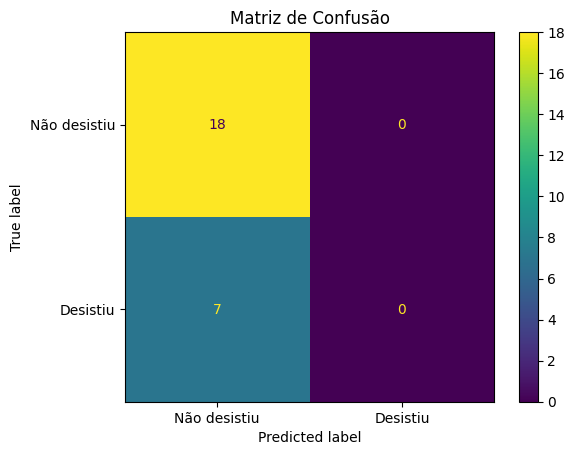

In [11]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não desistiu', 'Desistiu'])
disp.plot(values_format='d')
plt.title('Matriz de Confusão')
plt.show()


## Interpretação obrigatória

Respondam:

1. Quantos desistentes o modelo acertou?
2. Quantos desistentes o modelo não identificou?
3. O que é pior neste problema: falso positivo ou falso negativo?

Lembrem:

- Falso positivo: modelo prevê evasão, mas o aluno não evade;
- Falso negativo: modelo prevê permanência, mas o aluno evade.


**Resposta da equipe:**



In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 1. Carregamento e Seleção de Variáveis (Conforme seu notebook)
df = pd.read_csv('clean_data_limpo (1).csv')
target = 'desistiu'
variaveis_modelo = ['algebra_linear_e_geometria_analitica', 'calculo_i', 'comunicacao_e_expressao', 'fisica_i', 'fundamentos_de_quimica']

X = df[variaveis_modelo]
y = df[target]

# 2. Divisão Treino/Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# 3. Treinamento do Modelo
modelo = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000))
])
modelo.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg', LogisticRegression(max_iter=1000))])

# 11. Análise das probabilidades

A regressão logística estima a probabilidade de evasão.

Vamos observar a distribuição dessas probabilidades.


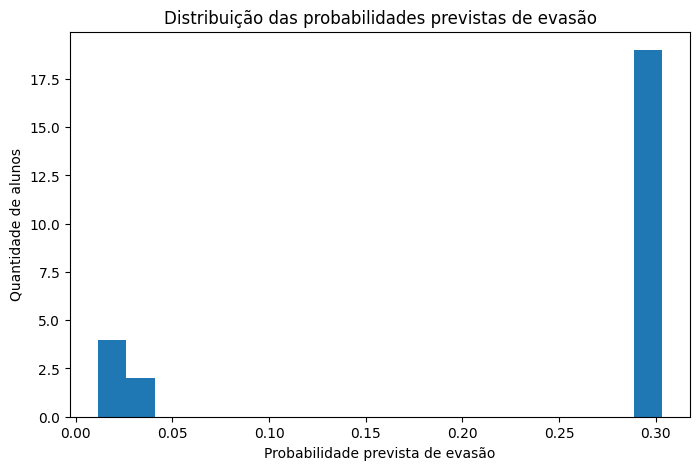

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(y_prob, bins=20)
plt.title('Distribuição das probabilidades previstas de evasão')
plt.xlabel('Probabilidade prevista de evasão')
plt.ylabel('Quantidade de alunos')
plt.show()


In [14]:
# Dez alunos com maior probabilidade prevista de evasão no conjunto de teste
top_risco = resultado_teste.sort_values('probabilidade_evasao', ascending=False).head(10)
display(top_risco)


,algebra_linear_e_geometria_analitica,calculo_i,comunicacao_e_expressao,fisica_i,fundamentos_de_quimica,real,previsto,probabilidade_evasao
54,1,1,1,1,1,1,0,0.303172
53,1,1,1,1,1,1,0,0.303172
14,1,1,1,1,1,0,0,0.303172
74,1,1,1,1,1,1,0,0.303172
26,1,1,1,1,1,0,0,0.303172
64,1,1,1,1,1,1,0,0.303172
2,1,1,1,1,1,0,0,0.303172
23,1,1,1,1,1,0,0,0.303172
69,1,1,1,1,1,1,0,0.303172
39,1,1,1,1,1,0,0,0.303172


Top 10 Alunos em Risco:
    real  probabilidade_evasao
54     1              0.303172
53     1              0.303172
14     0              0.303172
74     1              0.303172
26     0              0.303172
64     1              0.303172
2      0              0.303172
23     0              0.303172
69     1              0.303172
39     0              0.303172


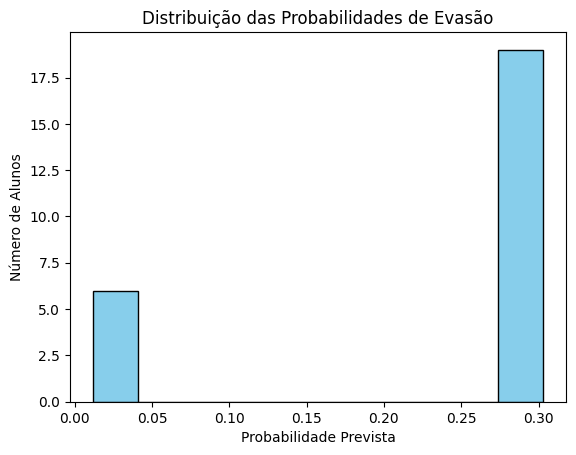

In [15]:
# Gerando probabilidades
y_prob = modelo.predict_proba(X_test)[:, 1]
y_pred = modelo.predict(X_test)

resultado_teste = X_test.copy()
resultado_teste['real'] = y_test.values
resultado_teste['previsto'] = y_pred
resultado_teste['probabilidade_evasao'] = y_prob

# 10 alunos com maior risco
top_risco = resultado_teste.sort_values('probabilidade_evasao', ascending=False).head(10)
print("Top 10 Alunos em Risco:")
print(top_risco[['real', 'probabilidade_evasao']])

# Histograma das probabilidades
plt.hist(y_prob, bins=10, color='skyblue', edgecolor='black')
plt.title('Distribuição das Probabilidades de Evasão')
plt.xlabel('Probabilidade Prevista')
plt.ylabel('Número de Alunos')
plt.show()

## Interpretação obrigatória

Respondam:

1. O modelo gerou muitos alunos com alta probabilidade de evasão?
2. Os alunos de maior risco realmente evadiram?
3. Como a faculdade poderia usar essa informação de forma responsável?


**Resposta da equipe:**



# 12. Interpretação das variáveis do modelo

Agora vamos olhar os coeficientes da regressão logística.

Atenção:

- Coeficiente positivo: aumenta a chance estimada de evasão;
- Coeficiente negativo: reduz a chance estimada de evasão;
- Quanto maior o valor absoluto, maior o peso da variável no modelo.

Esta interpretação deve ser feita com cuidado. Coeficiente não prova causalidade.


Influência das Variáveis (Coeficientes):
                               Variável  Coeficiente
0  algebra_linear_e_geometria_analitica     0.467995
2               comunicacao_e_expressao     0.410276
1                             calculo_i     0.121067
3                              fisica_i     0.013088
4                fundamentos_de_quimica     0.000000


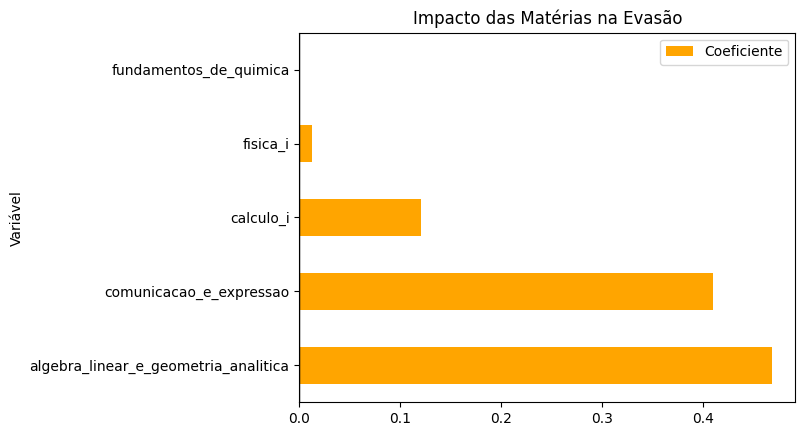

In [16]:
# Extraindo coeficientes do modelo dentro do pipeline
coeficientes = modelo.named_steps['logreg'].coef_[0]
importancia = pd.DataFrame({
    'Variável': variaveis_modelo,
    'Coeficiente': coeficientes
}).sort_values('Coeficiente', ascending=False)

print("Influência das Variáveis (Coeficientes):")
print(importancia)

# Gráfico de barras dos coeficientes
importancia.plot(kind='barh', x='Variável', y='Coeficiente', color='orange')
plt.title('Impacto das Matérias na Evasão')
plt.axvline(0, color='black', lw=1)
plt.show()

## Interpretação obrigatória

Respondam:

1. Quais variáveis mais aumentaram a chance estimada de evasão?
2. Quais variáveis mais reduziram a chance estimada de evasão?
3. Isso confirma o que vocês tinham observado nas etapas anteriores?
4. Alguma variável apresentou resultado inesperado?


**Resposta da equipe:**



# 13. Comparação com um modelo ingênuo

Um modelo só é útil se for melhor do que uma regra muito simples.

Exemplo de modelo ingênuo: prever sempre a classe mais frequente.


In [17]:
from sklearn.metrics import accuracy_score

# Acurácia do Modelo
acc_modelo = accuracy_score(y_test, y_pred)

# Acurácia do Modelo Ingênuo (chutar sempre 0 - não desistiu)
classe_majoritaria = y_train.mode()[0]
chute_ingenuo = np.repeat(classe_majoritaria, len(y_test))
acc_ingenuo = accuracy_score(y_test, chute_ingenuo)

print(f"Acurácia da Regressão Logística: {acc_modelo:.4f}")
print(f"Acurácia do Modelo Ingênuo: {acc_ingenuo:.4f}")

Acurácia da Regressão Logística: 0.7200
Acurácia do Modelo Ingênuo: 0.7200


## Interpretação obrigatória

Respondam:

1. A regressão logística foi melhor que o modelo ingênuo?
2. Se a diferença foi pequena, o que isso pode indicar?
3. O modelo realmente aprendeu algo útil?


**Resposta da equipe:**



# 14. Limitações do modelo

Nenhum modelo é perfeito.

Respondam obrigatoriamente:

1. Quais variáveis importantes podem estar faltando?
2. O modelo pode gerar algum tipo de viés?
3. O modelo deve ser usado sozinho para tomar decisão sobre alunos?
4. Existe risco de confundir associação com causalidade?


In [18]:
# Mostra colunas que NÃO foram usadas e poderiam ajudar
colunas_fora = [c for c in df.columns if c not in variaveis_modelo and c != target]
print("Variáveis disponíveis no CSV mas não usadas no modelo:")
print(colunas_fora)

Variáveis disponíveis no CSV mas não usadas no modelo:
['aluno_id', 'sexo', 'dist_cidade_km', 'ingresso__1', 'ingresso__2', 'ingresso__3', 'ingresso__4', 'ingresso__5', 'ingresso__6', 'ingresso__9', 'ingresso__21', 'ingresso__22', 'ingresso__27', 'ingresso__28', 'ingresso__31', 'ingresso__33', 'ingresso__34']


**Resposta da equipe:**



# 15. Conclusão final da Etapa 4

Respondam de forma completa:

1. O modelo conseguiu prever evasão de forma razoável?
2. Quais foram as variáveis mais importantes?
3. O resultado confirmou as análises anteriores?
4. Qual seria a principal recomendação para a instituição?
5. O que a equipe melhoraria em uma próxima versão do modelo?


**Resposta final da equipe:**



# Checklist antes da entrega

Antes de entregar, verifiquem:

- [ ] Expliquei a pergunta principal da equipe;
- [ ] Justifiquei as variáveis escolhidas;
- [ ] Separei treino e teste;
- [ ] Treinei a regressão logística;
- [ ] Apresentei accuracy e classification report;
- [ ] Interpretei a matriz de confusão;
- [ ] Analisei os coeficientes;
- [ ] Comparei com modelo ingênuo;
- [ ] Discuti limitações e ética;
- [ ] Escrevi uma conclusão final.


In [27]:
# =====================================================================
# PROCESSO COMPLETO: TREINAMENTO E EXPORTAÇÃO DIRETA PARA O BI
# =====================================================================
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 1. Garantir que a base de dados está carregada
# (O notebook usa o df carregado do seu arquivo clean_data_limpo)
df_bi = df.copy()

# 2. Definir as colunas que a equipe escolheu para o modelo
colunas_materias = [
    'algebra_linear_e_geometria_analitica',
    'calculo_i',
    'comunicacao_e_expressao',
    'fisica_i',
    'fundamentos_de_quimica'
]

# 3. Separar as variáveis (X) e o resultado real (y)
X_completo = df_bi[colunas_materias]
y_completo = df_bi['desistiu']

# 4. Criar e aplicar o Scaler (Normalização)
scaler_bi = StandardScaler()
X_completo_scaled = scaler_bi.fit_transform(X_completo)

# 5. Criar e treinar o modelo de Regressão Logística na hora
model_bi = LogisticRegression(random_state=42)
model_bi.fit(X_completo_scaled, y_completo)

# 6. Gerar as previsões e as probabilidades para o BI
df_bi['previsao_modelo'] = model_bi.predict(X_completo_scaled)
df_bi['probabilidade_desistir'] = model_bi.predict_proba(X_completo_scaled)[:, 1]

# 7. Traduzir os números para textos amigáveis para os filtros do dashboard
df_bi['status_real'] = df_bi['desistiu'].map({0: 'Regular / Ativo', 1: 'Evadido'})
df_bi['status_previsao'] = df_bi['previsao_modelo'].map({0: 'Regular / Ativo', 1: 'Evadido'})

# 8. Classificar o nível de risco de cada aluno
def mapear_risco(prob):
    if prob < 0.35:
        return 'Baixo Risco'
    elif prob < 0.70:
        return 'Médio Risco'
    else:
        return 'Alto Risco'

df_bi['classificacao_risco'] = df_bi['probabilidade_desistir'].apply(mapear_risco)

# 9. Salvar o arquivo final em CSV protegido contra erros de acentuação
nome_arquivo = 'dados_evasao_universidade.csv'
df_bi.to_csv(nome_arquivo, index=False, encoding='utf-8-sig')

print(f"✅ Sucesso absoluto! O arquivo '{nome_arquivo}' foi gerado com {df_bi.shape[0]} linhas.")

# 10. Baixar o arquivo automaticamente para o computador
from google.colab import files
files.download(nome_arquivo)

✅ Sucesso absoluto! O arquivo 'dados_evasao_universidade.csv' foi gerado com 99 linhas.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>